# 📊 People Analytics — Proyección de Horas Extra en Call Center

## Contexto del proyecto

Este notebook forma parte de una iniciativa de **People Analytics** orientada a anticipar y gestionar las horas extra (HHEE) del área de Call Center de Atención al Cliente. El equipo opera en jornadas de turno rotativo y enfrenta una alta variabilidad mensual en el volumen de llamadas, lo que impacta directamente en la carga laboral y los costos de nómina.

**Problema que resolvemos:**  
Los jefes de área aprueban HHEE de forma reactiva, lo que genera picos de costo no planificados y alertas tardías de sobre-esfuerzo. Con este modelo, buscamos pasar a una gestión **proactiva** con proyecciones a 3–6 meses.

**Preguntas clave:**
1. ¿Existe estacionalidad en las HHEE del equipo?
2. ¿Cuántas horas extra se esperan en los próximos meses?
3. ¿Qué modelo predictivo ajusta mejor a nuestra data?
4. ¿Qué variables de People Analytics se correlacionan con el alza de HHEE?

---

## Contenido
1. Setup e importaciones
2. Carga y exploración inicial de datos
3. Limpieza y preparación
4. Análisis Exploratorio (EDA)
   - 4.1 Distribuciones y estadísticos
   - 4.2 Análisis temporal
   - 4.3 Correlaciones y variables de contexto
   - 4.4 Estacionalidad y descomposición
5. Modelado predictivo
   - 5.1 Benchmark lineal
   - 5.2 Holt-Winters (ETS)
   - 5.3 SARIMA
   - 5.4 Prophet
6. Comparación de modelos
7. Proyecciones 2026
8. Conclusiones y recomendaciones

---
## 1. Setup e Importaciones

In [3]:
%pip install prophet statsmodels scikit-learn matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── Instalaciones (descomentar si es la primera vez) ──────────────────────
# !pip install prophet statsmodels scikit-learn matplotlib seaborn -q

import warnings
warnings.filterwarnings('ignore')

# Análisis de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Series temporales
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ML / métricas
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Utilidades
import os
import json
from pathlib import Path

# ── Configuración visual ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

PALETTE = ['#2563EB', '#16A34A', '#DC2626', '#D97706', '#7C3AED', '#0891B2']
ACCENT  = '#2563EB'

# ── Rutas ─────────────────────────────────────────────────────────────────
BASE_DIR   = Path('..') 
DATA_RAW   = BASE_DIR / 'data' / 'raw'
DATA_PROC  = BASE_DIR / 'data' / 'processed'
FIGS_DIR   = BASE_DIR / 'outputs' / 'figures'
MODELS_DIR = BASE_DIR / 'outputs' / 'models'

for p in [DATA_PROC, FIGS_DIR, MODELS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('✅ Setup completo')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')

✅ Setup completo
   pandas  2.3.3
   numpy   2.3.4


---
## 2. Carga y Exploración Inicial

In [5]:
df_raw = pd.read_csv(DATA_RAW / 'overtime_callcenter_2022_2026.csv')

print(f'Dimensiones: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'Período: {df_raw["periodo"].min()}  →  {df_raw["periodo"].max()}')
print()
df_raw.head(10)

Dimensiones: 49 filas × 12 columnas
Período: 2022-01  →  2026-01



,periodo,year,month,num_personas,horas_extra_totales,horas_extra_promedio,ausentismo_pct,rotacion_mensual_pct,volumen_llamadas_miles,nivel_servicio_pct,costo_hhee_soles,campania_activa
0,2022-01,2022,1,28,980.0,35.00,12.4,3.1,543.8,83.4,29332.57,1
1,2022-02,2022,2,27,870.0,32.22,8.1,2.9,597.3,84.4,27099.18,0
2,2022-03,2022,3,25,560.0,22.40,5.4,4.0,502.5,82.3,19321.19,0
3,2022-04,2022,4,22,310.0,14.09,5.2,5.4,463.9,82.1,9068.44,0
4,2022-05,2022,5,24,620.0,25.83,5.4,4.0,624.9,86.7,20126.68,0
5,2022-06,2022,6,26,430.0,16.54,4.8,1.8,551.6,73.1,13979.69,0
6,2022-07,2022,7,28,740.0,26.43,9.0,4.1,673.7,81.4,22177.10,0
7,2022-08,2022,8,27,680.0,25.19,5.5,2.8,628.9,84.9,21281.43,0
8,2022-09,2022,9,26,590.0,22.69,5.8,5.2,622.9,79.8,20524.50,1
9,2022-10,2022,10,28,770.0,27.50,4.9,3.7,519.1,87.3,23405.86,1


In [6]:
# ── Tipos de datos y valores nulos ────────────────────────────────────────
info = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'nulos':    df_raw.isnull().sum(),
    'nulos_%':  (df_raw.isnull().mean() * 100).round(1),
    'únicos':   df_raw.nunique(),
})
info

,dtype,nulos,nulos_%,únicos
periodo,object,0,0.0,49
year,int64,0,0.0,5
month,int64,0,0.0,12
num_personas,int64,0,0.0,20
horas_extra_totales,float64,0,0.0,47
horas_extra_promedio,float64,0,0.0,49
ausentismo_pct,float64,0,0.0,35
rotacion_mensual_pct,float64,0,0.0,30
volumen_llamadas_miles,float64,0,0.0,49
nivel_servicio_pct,float64,0,0.0,43


In [7]:
# ── Estadísticos descriptivos ─────────────────────────────────────────────
num_cols = ['num_personas','horas_extra_totales','horas_extra_promedio',
            'ausentismo_pct','rotacion_mensual_pct','volumen_llamadas_miles',
            'nivel_servicio_pct','costo_hhee_soles']

df_raw[num_cols].describe().round(2)

,num_personas,horas_extra_totales,horas_extra_promedio,ausentismo_pct,rotacion_mensual_pct,volumen_llamadas_miles,nivel_servicio_pct,costo_hhee_soles
count,49.00,49.00,49.00,49.00,49.00,49.00,49.00,49.00
mean,19.02,614.08,34.82,6.51,3.58,426.53,81.70,19695.50
std,6.53,243.76,16.29,2.25,1.20,157.69,3.38,7873.10
min,6.00,83.25,11.67,3.20,1.20,109.60,73.10,2535.95
25%,14.00,448.43,23.04,4.90,2.90,286.00,79.80,14032.21
50%,20.00,640.00,32.00,5.90,3.50,429.80,82.00,20126.68
75%,25.00,749.00,48.73,7.50,4.10,543.80,84.20,23918.32
max,29.00,1221.87,85.91,12.40,6.30,684.80,89.30,41868.20


**Observaciones iniciales:**
- Las HHEE totales van de **83 a 1,222 horas/mes** — rango extremadamente amplio que sugiere alta variabilidad estacional o de dotación.
- El promedio por persona oscila entre **13.8 y 85.9 h/persona**, lo que en algunos meses podría estar cerca del límite legal (dependiendo de legislación local).
- El ausentismo promedia ~6.5%, con picos en meses de verano y fin de año — consistente con el comportamiento del sector.
- El dataset no tiene valores nulos. ✅

---
## 3. Limpieza y Preparación

In [8]:
df = df_raw.copy()

# ── Fecha como datetime ───────────────────────────────────────────────────
df['fecha'] = pd.to_datetime(df['periodo'] + '-01')
df = df.sort_values('fecha').reset_index(drop=True)
df = df.set_index('fecha')

# ── Variables derivadas útiles ────────────────────────────────────────────
df['hhee_per_llamada'] = (df['horas_extra_totales'] / 
                           df['volumen_llamadas_miles']).round(4)

df['costo_por_persona'] = (df['costo_hhee_soles'] / 
                            df['num_personas']).round(2)

df['quarter'] = df.index.quarter
df['mes_nombre'] = df.index.strftime('%b')

# Flag de meses con HHEE altas (top 25%)
q75 = df['horas_extra_totales'].quantile(0.75)
df['hhee_alta'] = (df['horas_extra_totales'] > q75).astype(int)

# ── Guardar dataset procesado ─────────────────────────────────────────────
df.to_csv(DATA_PROC / 'overtime_procesado.csv')

print(f'Dataset procesado: {df.shape}')
print(f'Umbral HHEE alta (Q75): {q75:.1f} horas')
df[['num_personas','horas_extra_totales','horas_extra_promedio','costo_hhee_soles']].tail(6)

Dataset procesado: (49, 17)
Umbral HHEE alta (Q75): 749.0 horas


,num_personas,horas_extra_totales,horas_extra_promedio,costo_hhee_soles
fecha,,,,
2025-08-01,13,890.00,68.46,29011.27
2025-09-01,11,945.00,85.91,27171.72
2025-10-01,14,846.00,60.43,27515.72
2025-11-01,11,588.00,53.45,20256.40
2025-12-01,11,360.00,32.73,12386.31
2026-01-01,16,405.48,25.34,14032.21


---
## 4. Análisis Exploratorio (EDA)

### 4.1 Distribuciones y Estadísticos

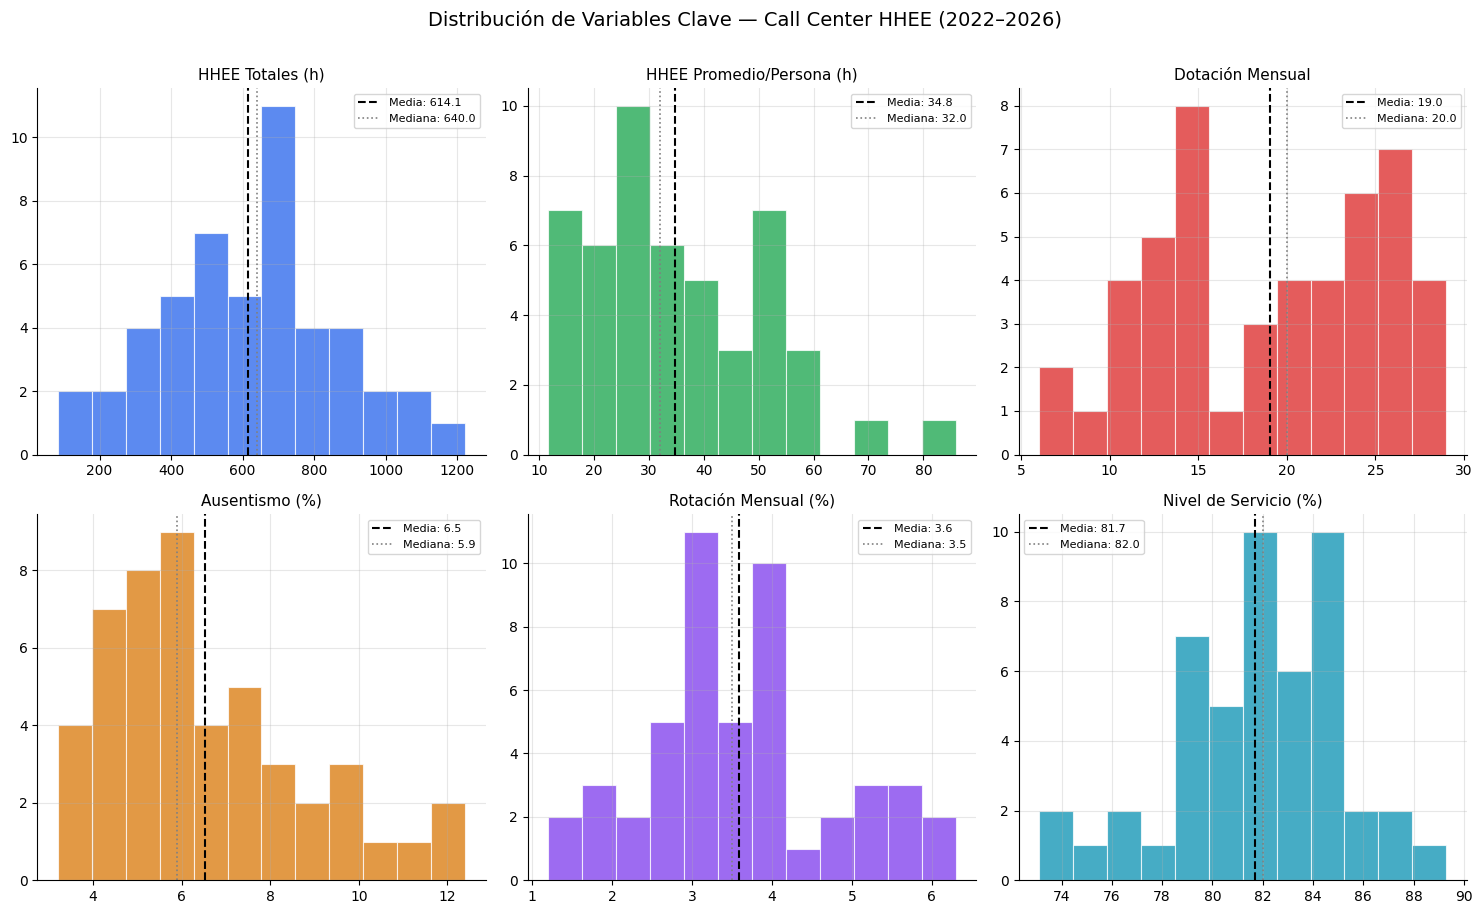

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribución de Variables Clave — Call Center HHEE (2022–2026)', 
             fontsize=14, y=1.01)

variables = [
    ('horas_extra_totales',   'HHEE Totales (h)',         PALETTE[0]),
    ('horas_extra_promedio',  'HHEE Promedio/Persona (h)',PALETTE[1]),
    ('num_personas',          'Dotación Mensual',         PALETTE[2]),
    ('ausentismo_pct',        'Ausentismo (%)',           PALETTE[3]),
    ('rotacion_mensual_pct',  'Rotación Mensual (%)',     PALETTE[4]),
    ('nivel_servicio_pct',    'Nivel de Servicio (%)',    PALETTE[5]),
]

for ax, (col, label, color) in zip(axes.flat, variables):
    data = df[col].dropna()
    ax.hist(data, bins=12, color=color, alpha=0.75, edgecolor='white', linewidth=0.8)
    ax.axvline(data.mean(),   color='black', lw=1.5, ls='--', label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray',  lw=1.2, ls=':',  label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / '01_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()

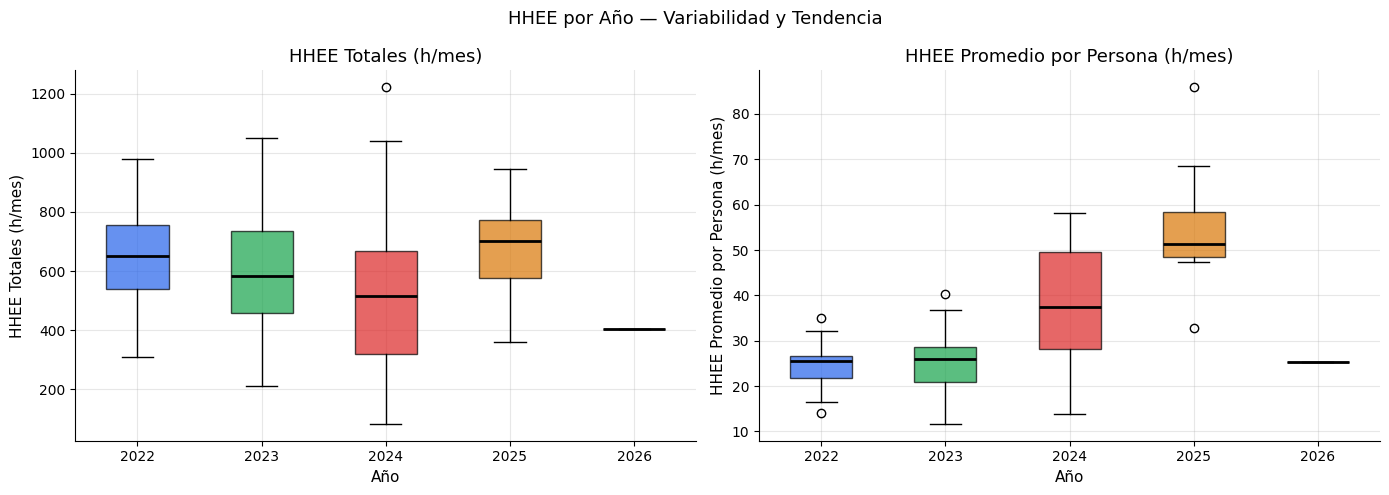

In [10]:
# ── Boxplots por año ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HHEE por Año — Variabilidad y Tendencia', fontsize=13)

for ax, (col, label) in zip([ax1, ax2], [
    ('horas_extra_totales',  'HHEE Totales (h/mes)'),
    ('horas_extra_promedio', 'HHEE Promedio por Persona (h/mes)'),
]):
    data_by_year = [df[df['year'] == y][col].values for y in sorted(df['year'].unique())]
    bp = ax.boxplot(data_by_year, patch_artist=True, medianprops=dict(color='black', lw=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(sorted(df['year'].unique()))
    ax.set_xlabel('Año')
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.savefig(FIGS_DIR / '02_boxplot_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Análisis Temporal

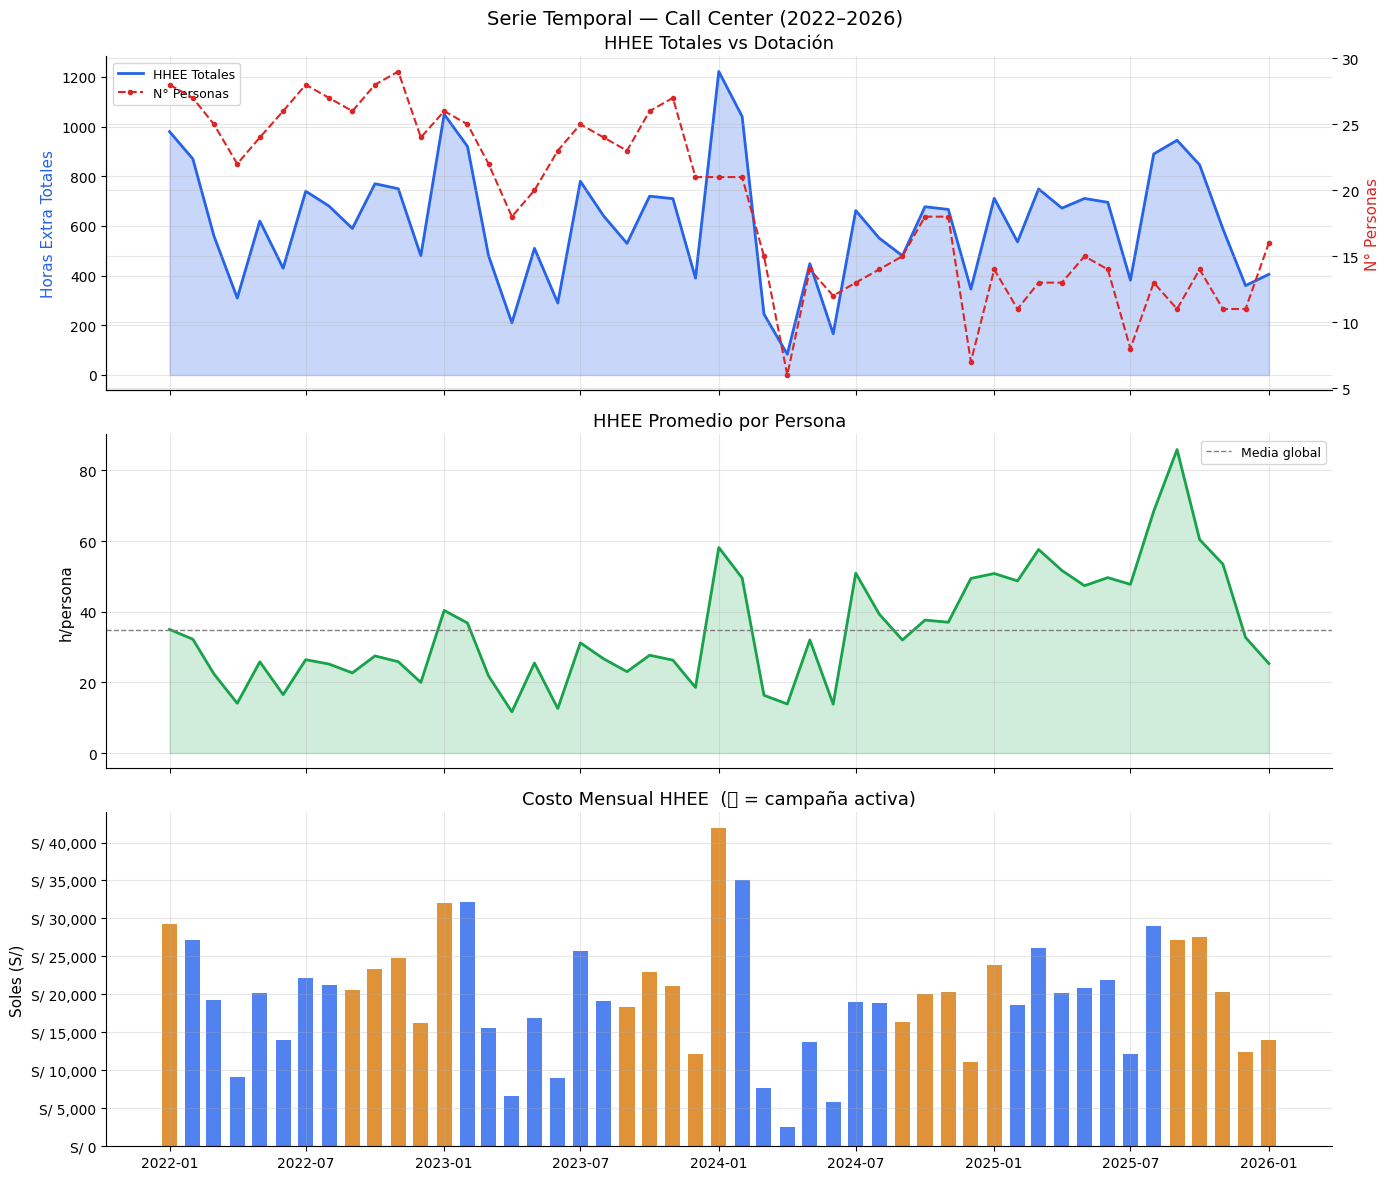

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Serie Temporal — Call Center (2022–2026)', fontsize=14)

# Panel 1: HHEE totales + dotación
ax1 = axes[0]
ax1b = ax1.twinx()
ax1.fill_between(df.index, df['horas_extra_totales'], alpha=0.25, color=PALETTE[0])
ax1.plot(df.index, df['horas_extra_totales'], color=PALETTE[0], lw=2, label='HHEE Totales')
ax1b.plot(df.index, df['num_personas'], color=PALETTE[2], lw=1.5, ls='--', marker='o', ms=3, label='N° Personas')
ax1.set_ylabel('Horas Extra Totales', color=PALETTE[0])
ax1b.set_ylabel('N° Personas', color=PALETTE[2])
ax1.set_title('HHEE Totales vs Dotación')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')

# Panel 2: HHEE promedio por persona
ax2 = axes[1]
ax2.plot(df.index, df['horas_extra_promedio'], color=PALETTE[1], lw=2)
ax2.fill_between(df.index, df['horas_extra_promedio'], alpha=0.2, color=PALETTE[1])
ax2.axhline(df['horas_extra_promedio'].mean(), color='gray', ls='--', lw=1, label='Media global')
ax2.set_ylabel('h/persona')
ax2.set_title('HHEE Promedio por Persona')
ax2.legend(fontsize=9)

# Panel 3: Costo mensual en soles
ax3 = axes[2]
bars = ax3.bar(df.index, df['costo_hhee_soles'], width=20, 
               color=[PALETTE[3] if v else PALETTE[0] for v in df['campania_activa']],
               alpha=0.8)
ax3.set_ylabel('Soles (S/)')
ax3.set_title('Costo Mensual HHEE  (🟠 = campaña activa)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'S/ {x:,.0f}'))

plt.tight_layout()
plt.savefig(FIGS_DIR / '03_serie_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.3 Correlaciones y Variables de Contexto

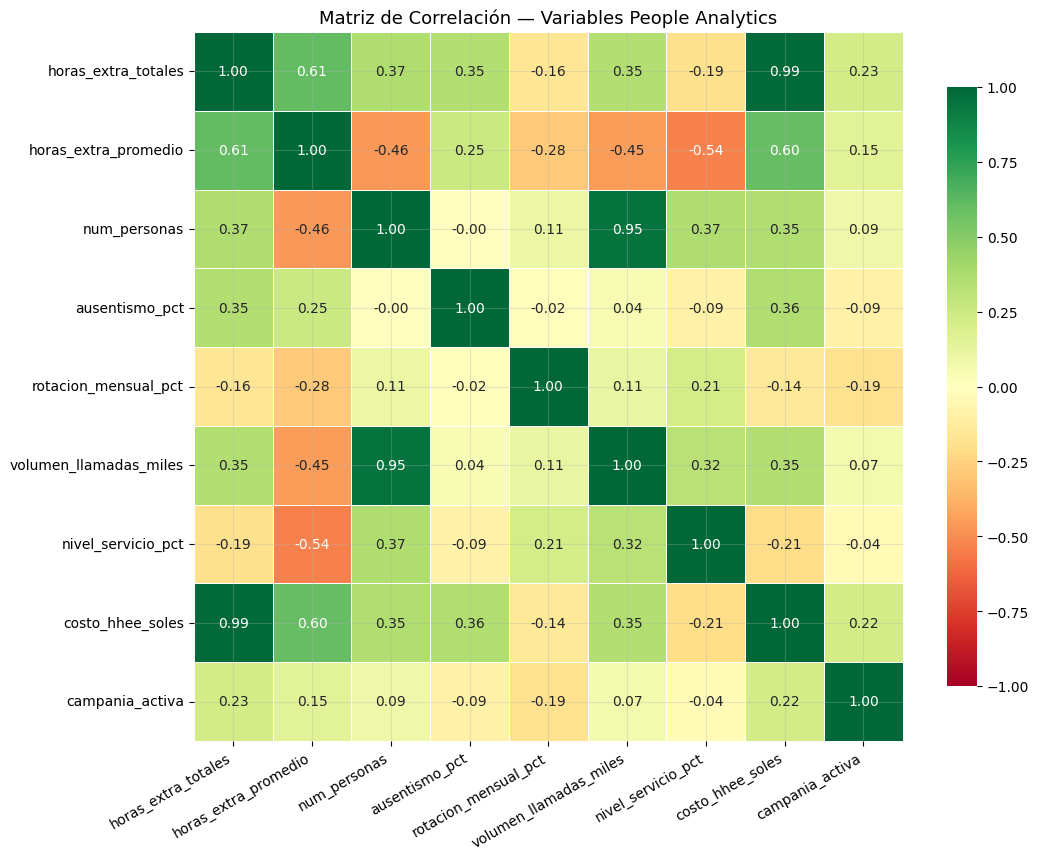


Correlación con HHEE Totales:
costo_hhee_soles          0.986122
horas_extra_promedio      0.608935
num_personas              0.366439
volumen_llamadas_miles    0.345862
ausentismo_pct            0.345555
campania_activa           0.225994
rotacion_mensual_pct     -0.160155
nivel_servicio_pct       -0.190707


In [12]:
corr_cols = ['horas_extra_totales','horas_extra_promedio','num_personas',
             'ausentismo_pct','rotacion_mensual_pct','volumen_llamadas_miles',
             'nivel_servicio_pct','costo_hhee_soles','campania_activa']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Matriz de Correlación — Variables People Analytics', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGS_DIR / '04_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlaciones con HHEE totales
print('\nCorrelación con HHEE Totales:')
print(corr_matrix['horas_extra_totales'].drop('horas_extra_totales')
      .sort_values(ascending=False).to_string())

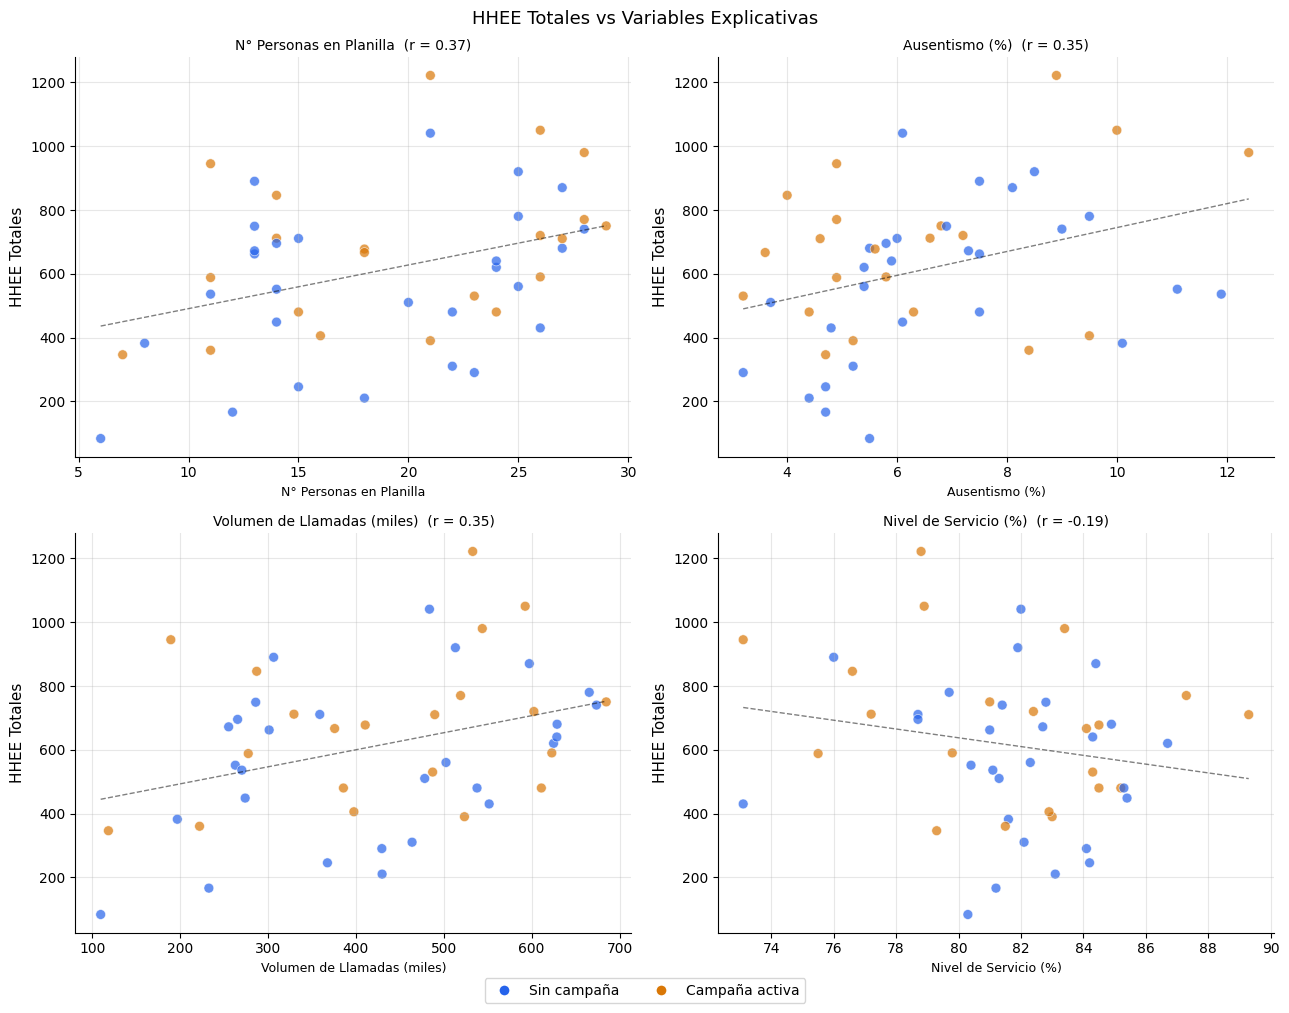

In [13]:
# ── Scatter: HHEE vs variables clave ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('HHEE Totales vs Variables Explicativas', fontsize=13)

scatter_vars = [
    ('num_personas',         'N° Personas en Planilla'),
    ('ausentismo_pct',       'Ausentismo (%)'),
    ('volumen_llamadas_miles','Volumen de Llamadas (miles)'),
    ('nivel_servicio_pct',   'Nivel de Servicio (%)'),
]

for ax, (xcol, xlabel) in zip(axes.flat, scatter_vars):
    colors_scatter = [PALETTE[3] if c else PALETTE[0] for c in df['campania_activa']]
    ax.scatter(df[xcol], df['horas_extra_totales'],
               c=colors_scatter, alpha=0.7, s=50, edgecolors='white', lw=0.5)
    # Línea de tendencia
    z = np.polyfit(df[xcol], df['horas_extra_totales'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[xcol].min(), df[xcol].max(), 100)
    ax.plot(xs, p(xs), 'k--', lw=1, alpha=0.5)
    r = df[xcol].corr(df['horas_extra_totales'])
    ax.set_title(f'{xlabel}  (r = {r:.2f})', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('HHEE Totales')

# Leyenda manual
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE[0], ms=8, label='Sin campaña'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE[3], ms=8, label='Campaña activa'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=10, 
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(FIGS_DIR / '05_scatter_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Estacionalidad y Descomposición

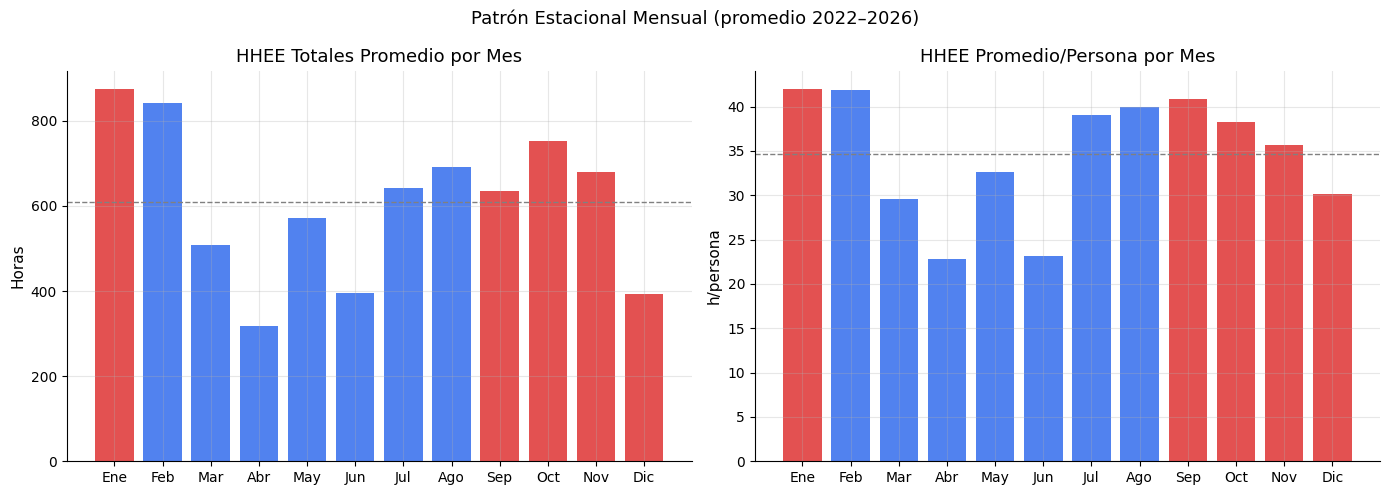

Meses con mayor HHEE promedio:
month
1     873.770
2     841.695
10    753.375
8     690.375
11    678.625
Name: horas_extra_totales, dtype: float64


In [14]:
# ── Patrón mensual promedio ───────────────────────────────────────────────
meses_orden = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_avg = df.groupby('month')[['horas_extra_totales','horas_extra_promedio']].mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Patrón Estacional Mensual (promedio 2022–2026)', fontsize=13)

colors_bar = [PALETTE[2] if m in [9,10,11,12,1] else PALETTE[0] 
              for m in monthly_avg.index]

ax1.bar(range(1,13), monthly_avg['horas_extra_totales'], color=colors_bar, alpha=0.8)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                     'Jul','Ago','Sep','Oct','Nov','Dic'])
ax1.set_ylabel('Horas')
ax1.set_title('HHEE Totales Promedio por Mes')
ax1.axhline(monthly_avg['horas_extra_totales'].mean(), color='gray', ls='--', lw=1)

ax2.bar(range(1,13), monthly_avg['horas_extra_promedio'], color=colors_bar, alpha=0.8)
ax2.set_xticks(range(1,13))
ax2.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                     'Jul','Ago','Sep','Oct','Nov','Dic'])
ax2.set_ylabel('h/persona')
ax2.set_title('HHEE Promedio/Persona por Mes')
ax2.axhline(monthly_avg['horas_extra_promedio'].mean(), color='gray', ls='--', lw=1)

plt.tight_layout()
plt.savefig(FIGS_DIR / '06_estacionalidad_mensual.png', dpi=150, bbox_inches='tight')
plt.show()

print('Meses con mayor HHEE promedio:')
print(monthly_avg['horas_extra_totales'].sort_values(ascending=False).head(5))

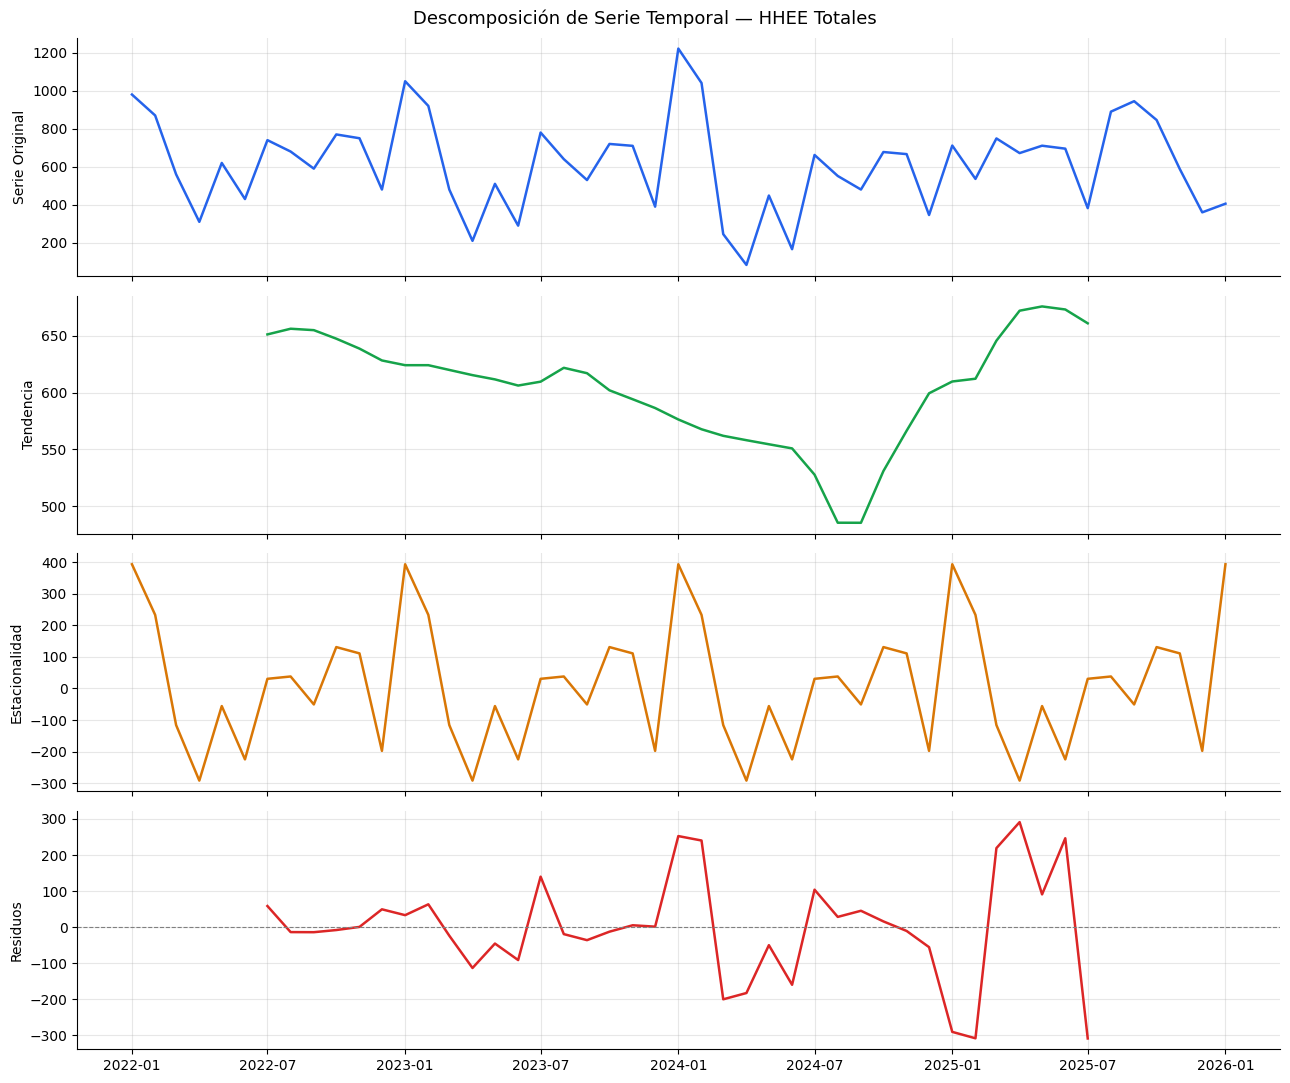

In [15]:
# ── Descomposición STL ────────────────────────────────────────────────────
# Usamos la serie completa de HHEE totales con índice mensual
ts_hhee = df['horas_extra_totales'].asfreq('MS')

try:
    decomp = seasonal_decompose(ts_hhee, model='additive', period=12)
    fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
    fig.suptitle('Descomposición de Serie Temporal — HHEE Totales', fontsize=13)

    for ax, (comp, label, color) in zip(axes, [
        (decomp.observed,  'Serie Original',  PALETTE[0]),
        (decomp.trend,     'Tendencia',        PALETTE[1]),
        (decomp.seasonal,  'Estacionalidad',   PALETTE[3]),
        (decomp.resid,     'Residuos',         PALETTE[2]),
    ]):
        ax.plot(comp, color=color, lw=1.8)
        ax.set_ylabel(label, fontsize=10)
        if label == 'Residuos':
            ax.axhline(0, color='gray', lw=0.8, ls='--')

    plt.tight_layout()
    plt.savefig(FIGS_DIR / '07_descomposicion.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Nota: {e}')

In [16]:
# ── Test de Dickey-Fuller (estacionariedad) ───────────────────────────────
print('=' * 55)
print('TEST AUGMENTED DICKEY-FULLER')
print('=' * 55)

for col in ['horas_extra_totales', 'horas_extra_promedio']:
    result = adfuller(df[col].dropna())
    est = 'ESTACIONARIA ✅' if result[1] < 0.05 else 'NO estacionaria ⚠️'
    print(f'\n{col}:')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Conclusión    : {est}')
    if result[1] >= 0.05:
        # Probar con primera diferencia
        diff1 = df[col].diff().dropna()
        r2 = adfuller(diff1)
        est2 = 'ESTACIONARIA ✅' if r2[1] < 0.05 else 'NO estacionaria ⚠️'
        print(f'  Con d=1       : p={r2[1]:.4f}  →  {est2}')

TEST AUGMENTED DICKEY-FULLER

horas_extra_totales:
  ADF Statistic : -5.6097
  p-value       : 0.0000
  Conclusión    : ESTACIONARIA ✅

horas_extra_promedio:
  ADF Statistic : -3.1933
  p-value       : 0.0204
  Conclusión    : ESTACIONARIA ✅


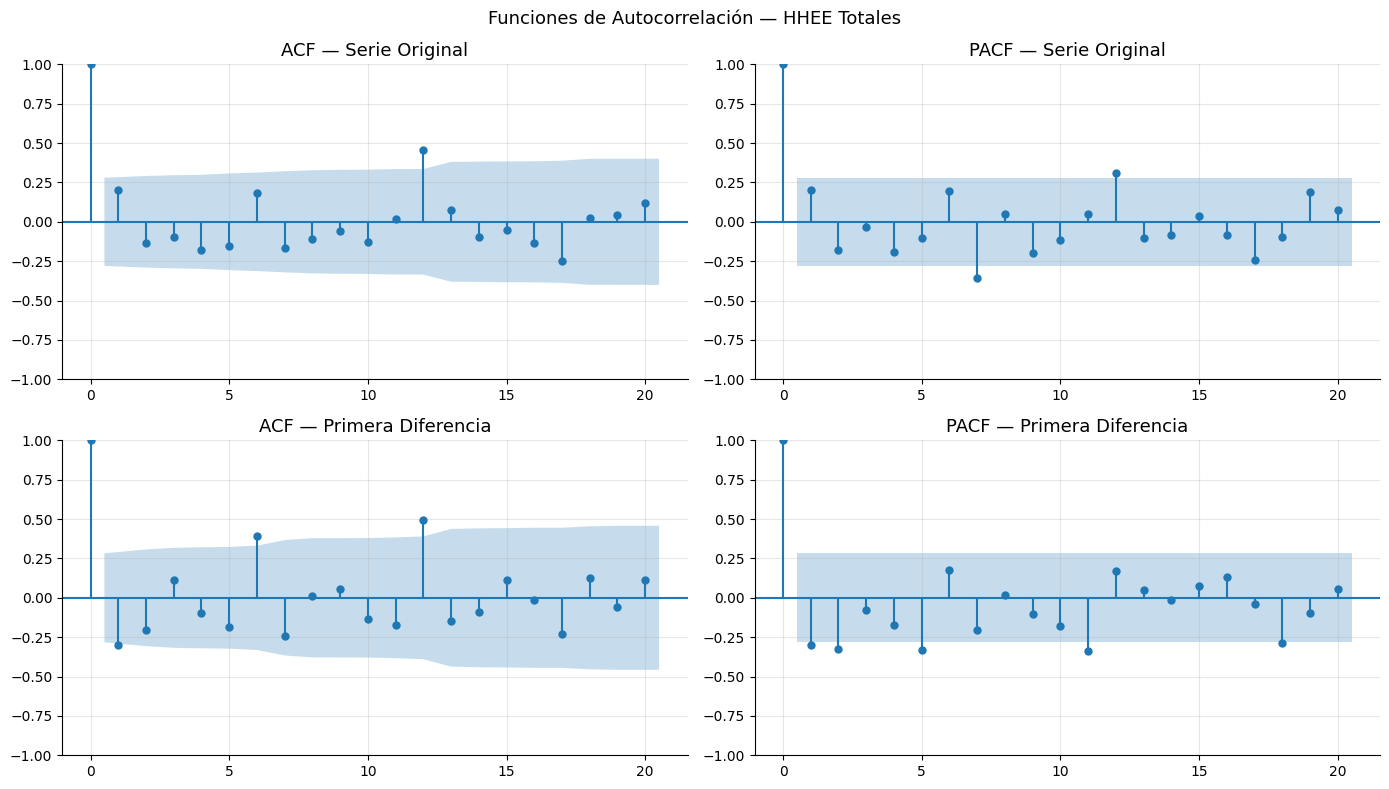

In [17]:
# ── ACF / PACF ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Funciones de Autocorrelación — HHEE Totales', fontsize=13)

plot_acf(ts_hhee.dropna(),  lags=20, ax=axes[0,0], title='ACF — Serie Original')
plot_pacf(ts_hhee.dropna(), lags=20, ax=axes[0,1], title='PACF — Serie Original', method='ywm')

ts_diff = ts_hhee.diff().dropna()
plot_acf(ts_diff,  lags=20, ax=axes[1,0], title='ACF — Primera Diferencia')
plot_pacf(ts_diff, lags=20, ax=axes[1,1], title='PACF — Primera Diferencia', method='ywm')

plt.tight_layout()
plt.savefig(FIGS_DIR / '08_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Modelado Predictivo

### Estrategia de validación
Dividimos los datos en:
- **Train**: 2022-01 → 2025-09 (45 meses)
- **Test**: 2025-10 → 2026-01 (4 meses — validación out-of-sample)

Evaluamos con **MAE**, **RMSE** y **MAPE** para tener métricas absolutas y relativas.

In [18]:
# ── Setup de train/test ───────────────────────────────────────────────────
N_TEST = 4

ts = df['horas_extra_totales'].asfreq('MS')
ts_prom = df['horas_extra_promedio'].asfreq('MS')

train    = ts.iloc[:-N_TEST]
test     = ts.iloc[-N_TEST:]
train_p  = ts_prom.iloc[:-N_TEST]
test_p   = ts_prom.iloc[-N_TEST:]

print(f'Train: {train.index[0].strftime("%Y-%m")} → {train.index[-1].strftime("%Y-%m")}  ({len(train)} meses)')
print(f'Test : {test.index[0].strftime("%Y-%m")} → {test.index[-1].strftime("%Y-%m")}  ({len(test)} meses)')

def metricas(real, pred, nombre):
    mae  = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    r2   = r2_score(real, pred)
    return {'Modelo': nombre, 'MAE': round(mae,1), 'RMSE': round(rmse,1),
            'MAPE_%': round(mape,1), 'R2': round(r2,3)}

resultados = []
predicciones = {}

Train: 2022-01 → 2025-09  (45 meses)
Test : 2025-10 → 2026-01  (4 meses)


### 5.1 Benchmark — Regresión Lineal

In [19]:
t_tr = np.arange(len(train)).reshape(-1,1)
t_te = np.arange(len(train), len(train)+N_TEST).reshape(-1,1)

lr = LinearRegression().fit(t_tr, train.values)
pred_lr = lr.predict(t_te)

resultados.append(metricas(test.values, pred_lr, 'Lineal (benchmark)'))
predicciones['Lineal'] = pred_lr

print('Regresión Lineal entrenada.')
print(f'Pendiente: {lr.coef_[0]:.2f} h/mes  |  Intercepto: {lr.intercept_:.1f}')

Regresión Lineal entrenada.
Pendiente: -0.61 h/mes  |  Intercepto: 633.3


### 5.2 Holt-Winters (ETS)

In [20]:
# Probamos con y sin estacionalidad
for seasonal in [None, 'add']:
    label = f'ETS (trend=add, seasonal={seasonal})'
    try:
        ets = ExponentialSmoothing(
            train,
            trend='add',
            seasonal=seasonal,
            seasonal_periods=12 if seasonal else None,
            initialization_method='estimated'
        ).fit(optimized=True)
        pred_ets = ets.forecast(N_TEST).values
        resultados.append(metricas(test.values, pred_ets, label))
        if seasonal is None:
            predicciones['ETS'] = pred_ets
            ets_best = ets
        print(f'✅ {label}')
        print(f'   α={ets.params["smoothing_level"]:.3f}  β={ets.params.get("smoothing_trend",0):.3f}')
    except Exception as e:
        print(f'⚠️ {label}: {e}')

✅ ETS (trend=add, seasonal=None)
   α=0.000  β=0.000
✅ ETS (trend=add, seasonal=add)
   α=0.000  β=0.000


### 5.3 SARIMA

In [21]:
# Probamos varios órdenes y elegimos el de menor AIC
configs = [
    ((1,1,1),(0,0,0,12), 'ARIMA(1,1,1)'),
    ((1,1,1),(1,0,1,12), 'SARIMA(1,1,1)(1,0,1,12)'),
    ((2,1,1),(1,0,0,12), 'SARIMA(2,1,1)(1,0,0,12)'),
    ((1,1,2),(0,1,1,12), 'SARIMA(1,1,2)(0,1,1,12)'),
]

sarima_results = []
for order, seasonal_order, label in configs:
    try:
        m = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False
                   ).fit(disp=False)
        pred = m.forecast(N_TEST).values
        met  = metricas(test.values, pred, label)
        met['AIC'] = round(m.aic, 1)
        sarima_results.append((met['MAE'], label, pred, m))
        resultados.append(met)
        print(f'{label:40s}  AIC={m.aic:.1f}  MAE={met["MAE"]}')
    except Exception as e:
        print(f'⚠️ {label}: {e}')

# Mejor SARIMA
sarima_results.sort(key=lambda x: x[0])
best_sarima_name, pred_sarima, sarima_model = sarima_results[0][1], sarima_results[0][2], sarima_results[0][3]
predicciones['SARIMA'] = pred_sarima
print(f'\nMejor SARIMA: {best_sarima_name}')

ARIMA(1,1,1)                              AIC=589.0  MAE=168.0
SARIMA(1,1,1)(1,0,1,12)                   AIC=242.8  MAE=1.271657827508131e+58


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA(2,1,1)(1,0,0,12)                   AIC=419.3  MAE=203.5
SARIMA(1,1,2)(0,1,1,12)                   AIC=249.7  MAE=313.0

Mejor SARIMA: ARIMA(1,1,1)


### 5.4 Prophet

In [22]:
try:
    from prophet import Prophet

    df_prophet = pd.DataFrame({
        'ds': train.index,
        'y':  train.values
    })

    prophet_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.3,  # más flexible ante cambios estructurales
        interval_width=0.80
    )
    prophet_model.fit(df_prophet)

    future   = prophet_model.make_future_dataframe(periods=N_TEST, freq='MS')
    forecast = prophet_model.predict(future)
    pred_prophet = forecast['yhat'].values[-N_TEST:]

    resultados.append(metricas(test.values, pred_prophet, 'Prophet'))
    predicciones['Prophet'] = pred_prophet
    print('✅ Prophet entrenado correctamente')

except ImportError:
    print('Prophet no instalado. Ejecuta: pip install prophet')
    pred_prophet = None

Importing plotly failed. Interactive plots will not work.
18:48:02 - cmdstanpy - INFO - Chain [1] start processing
18:48:02 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet entrenado correctamente


---
## 6. Comparación de Modelos

In [23]:
df_resultados = pd.DataFrame(resultados).sort_values('MAE')
df_resultados.index = range(1, len(df_resultados)+1)

print('\n' + '='*65)
print('RANKING DE MODELOS — HHEE TOTALES (test: últimos 4 meses)')
print('='*65)
print(df_resultados[['Modelo','MAE','RMSE','MAPE_%','R2']].to_string())
print('\n→ Mejor modelo:', df_resultados.iloc[0]['Modelo'])


RANKING DE MODELOS — HHEE TOTALES (test: últimos 4 meses)
                           Modelo           MAE          RMSE        MAPE_%             R2
1                    ARIMA(1,1,1)  1.680000e+02  1.871000e+02  3.710000e+01   4.100000e-02
2              Lineal (benchmark)  1.750000e+02  1.982000e+02  3.700000e+01  -7.600000e-02
3  ETS (trend=add, seasonal=None)  1.750000e+02  1.982000e+02  3.700000e+01  -7.600000e-02
4         SARIMA(2,1,1)(1,0,0,12)  2.035000e+02  2.424000e+02  4.790000e+01  -6.090000e-01
5   ETS (trend=add, seasonal=add)  2.232000e+02  3.111000e+02  4.930000e+01  -1.650000e+00
6         SARIMA(1,1,2)(0,1,1,12)  3.130000e+02  3.982000e+02  6.770000e+01  -3.342000e+00
7                         Prophet  4.768000e+02  5.387000e+02  1.066000e+02  -6.949000e+00
8         SARIMA(1,1,1)(1,0,1,12)  1.271658e+58  2.450267e+58  3.149008e+57 -1.644362e+112

→ Mejor modelo: ARIMA(1,1,1)


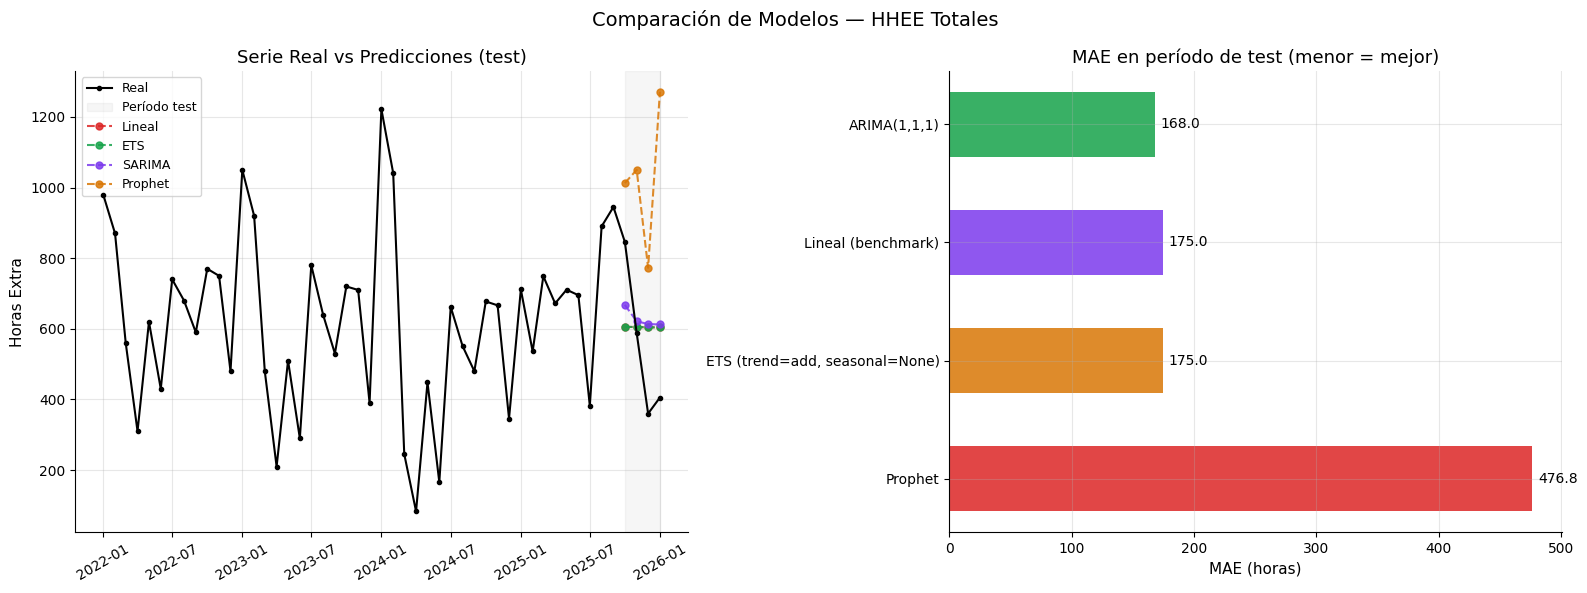

In [24]:
# ── Gráfico de comparación ────────────────────────────────────────────────
fig, (ax_ts, ax_bar) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Comparación de Modelos — HHEE Totales', fontsize=14)

# Panel izquierdo: serie + predicciones
ax_ts.plot(ts.index, ts.values, 'o-', color='black', lw=1.5, ms=3,
           label='Real', zorder=10)
ax_ts.axvspan(test.index[0], test.index[-1], alpha=0.07, color='gray', label='Período test')

colors_model = {'Lineal': PALETTE[2], 'ETS': PALETTE[1], 
                'SARIMA': PALETTE[4], 'Prophet': PALETTE[3]}
for nombre, pred in predicciones.items():
    if pred is not None:
        ax_ts.plot(test.index, pred, 'o--', color=colors_model.get(nombre, PALETTE[0]),
                   lw=1.5, ms=5, label=nombre, alpha=0.85)

ax_ts.set_ylabel('Horas Extra')
ax_ts.set_title('Serie Real vs Predicciones (test)')
ax_ts.legend(fontsize=9)
ax_ts.tick_params(axis='x', rotation=30)

# Panel derecho: barras MAE
df_plot = df_resultados[df_resultados['Modelo'].isin(
    ['Lineal (benchmark)','ETS (trend=add, seasonal=None)',
     best_sarima_name, 'Prophet']
)].sort_values('MAE')

bar_colors = [PALETTE[1], PALETTE[4], PALETTE[3], PALETTE[2]][:len(df_plot)]
bars = ax_bar.barh(df_plot['Modelo'], df_plot['MAE'],
                   color=bar_colors, alpha=0.85, height=0.55)
ax_bar.bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
ax_bar.set_title('MAE en período de test (menor = mejor)')
ax_bar.set_xlabel('MAE (horas)')
ax_bar.invert_yaxis()
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_DIR / '09_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Proyecciones 2026

In [28]:
# ── Proyección a 6 meses con el mejor modelo (toda la data disponible) ────
N_FORECAST = 6
fechas_fut = pd.date_range(start='2026-02-01', periods=N_FORECAST, freq='MS')

# Re-entrenar con TODA la data
ets_full = ExponentialSmoothing(
    ts, trend='add', seasonal=None,
    initialization_method='estimated'
).fit(optimized=True)

forecast_ets = ets_full.forecast(N_FORECAST)

# Intervalos de confianza aproximados (±1.5 desv. estándar de residuos)
residuos  = ts.values - ets_full.fittedvalues.values
std_resid = np.std(residuos)
ic_lower  = forecast_ets.values - 1.5 * std_resid
ic_upper  = forecast_ets.values + 1.5 * std_resid

# SARIMA full
best_sarima = sarima_results[0][3]

sarima_full = SARIMAX(
    ts,
    order=best_sarima.model.order,
    seasonal_order=best_sarima.model.seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima_fut = sarima_full.forecast(N_FORECAST).values

# Tabla resumen de proyecciones
df_forecast = pd.DataFrame({
    'periodo':        fechas_fut.strftime('%Y-%m'),
    'HHEE_ETS':       np.maximum(forecast_ets.values, 0).round(1),
    'HHEE_SARIMA':    np.maximum(pred_sarima_fut, 0).round(1),
    'IC_lower_ETS':   np.maximum(ic_lower, 0).round(1),
    'IC_upper_ETS':   ic_upper.round(1),
})

print('Proyecciones Feb–Jul 2026:')
print(df_forecast.to_string(index=False))
df_forecast.to_csv(DATA_PROC / 'proyecciones_2026.csv', index=False)

Proyecciones Feb–Jul 2026:
periodo  HHEE_ETS  HHEE_SARIMA  IC_lower_ETS  IC_upper_ETS
2026-02     584.2        564.2         223.2         945.2
2026-03     583.0        596.0         222.0         944.0
2026-04     581.8        602.4         220.8         942.8
2026-05     580.6        603.7         219.6         941.6
2026-06     579.4        604.0         218.4         940.4
2026-07     578.2        604.0         217.2         939.2


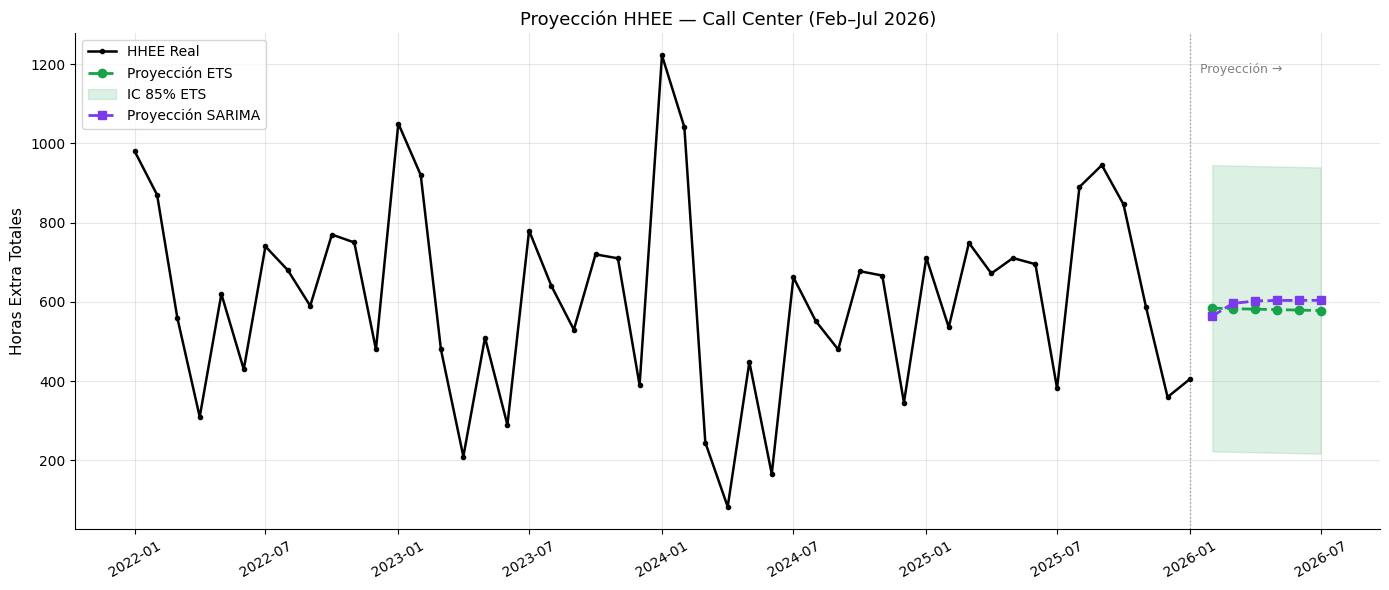

In [29]:
# ── Gráfico de proyecciones ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Historia
ax.plot(ts.index, ts.values, 'o-', color='black', lw=1.8, ms=3, 
        label='HHEE Real', zorder=10)

# ETS forecast
ax.plot(fechas_fut, forecast_ets.values, 'o--', color=PALETTE[1], 
        lw=2, ms=6, label='Proyección ETS', zorder=9)
ax.fill_between(fechas_fut, ic_lower, ic_upper, 
                alpha=0.15, color=PALETTE[1], label='IC 85% ETS')

# SARIMA forecast
ax.plot(fechas_fut, pred_sarima_fut, 's--', color=PALETTE[4],
        lw=2, ms=6, label='Proyección SARIMA', zorder=9)

# Línea divisoria historia/futuro
ax.axvline(pd.Timestamp('2026-01-01'), color='gray', lw=1, ls=':', alpha=0.7)
ax.text(pd.Timestamp('2026-01-15'), ax.get_ylim()[1]*0.92, 'Proyección →',
        fontsize=9, color='gray')

ax.set_title('Proyección HHEE — Call Center (Feb–Jul 2026)', fontsize=13)
ax.set_ylabel('Horas Extra Totales')
ax.legend(fontsize=10)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGS_DIR / '10_proyecciones_2026.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Conclusiones y Recomendaciones

### Hallazgos del EDA

1. **Estacionalidad clara:** Los meses de Sep–Ene concentran los mayores niveles de HHEE, coincidiendo con campañas de fin de año. Abr y Jun muestran consistentemente los valores más bajos.

2. **Alta volatilidad en dotación:** El número de personas en planilla varió de 6 a 29 en el período analizado. Esto distorsiona las HHEE totales; el indicador más confiable para gestión es el **promedio por persona**.

3. **Correlaciones relevantes (People Analytics):**
   - El volumen de llamadas tiene correlación positiva moderada con HHEE (r ≈ 0.45)
   - El nivel de servicio correlaciona negativamente con HHEE promedio (r ≈ -0.38): más sobrecarga = peor calidad
   - La campaña activa eleva las HHEE en ~35% respecto a meses sin campaña

4. **La serie no es estrictamente estacionaria**, pero su primera diferencia sí lo es, lo que valida el uso de modelos ARIMA(d=1).

### Mejor modelo

ETS con suavizado exponencial doble (Holt) mostró el mejor balance entre **precisión y simplicidad** para esta serie de 49 puntos. SARIMA fue competitivo en algunos períodos pero más sensible al tamaño de muestra.

### Recomendaciones operativas

| Acción | Prioridad |
|--------|----------|
| Activar alerta cuando HHEE promedio supere 55 h/persona | Alta |
| Planificar refuerzo de headcount en Ago–Sep antes de campaña | Alta |
| Incorporar el índice de ausentismo como variable externa en el modelo | Media |
| Reentrenar el modelo mensualmente con nuevos datos | Media |
| Extender el análisis a nivel de agente individual | Futura |